In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/trustmesh_economic_data.csv",
    parse_dates=["month"],
    keep_default_na=False
)

df = df.sort_values(["business_id", "month"])

# Recreate engineered features
df["cash_flow_margin"] = (
    df["adjusted_cash_flow"] / df["adjusted_income"] * 100
).round(2)

df["savings_rate"] = (
    df["savings_amount"] / df["adjusted_income"] * 100
).clip(0, 100).round(2)

df["expense_to_income_ratio"] = (
    df["adjusted_expenses"] / df["adjusted_income"] * 100
).round(2)

df["income_to_expense_ratio"] = (
    df["adjusted_income"] / df["adjusted_expenses"]
).round(2)

df["payment_behavior_score"] = (
    0.6 * df["payment_discipline_pct"]
    + 0.4 * df["supplier_reliability_pct"]
).round(2)

df["operational_behavior_score"] = (
    0.5 * df["business_continuity_pct"]
    + 0.5 * df["demand_stability_pct"]
).round(2)

df["digital_payment_strength"] = (
    df["digital_payment_pct"] / 100
).round(3)

df["shock_exposure"] = (
    df["shock_type"] != "None"
).astype(int)

df["financial_stress_pct"] = (
    0.6 * df["expense_burden_pct"].clip(0, 100)
    + 0.4 * (100 - df["cash_flow_margin"].clip(0, 100))
).round(2)

df["reputation_momentum"] = (
    df.groupby("business_id")["economic_reputation_index"]
      .diff()
      .round(2)
)

df["cash_flow_momentum"] = (
    df.groupby("business_id")["adjusted_cash_flow"]
      .diff()
      .round(2)
)

print(f"Dataset shape: {df.shape}")

Dataset shape: (12000, 43)


In [2]:

behavior_cols = {
    "financial_health_pct": "mean",
    "operational_stability_pct": "mean",
    "resilience_pct": "mean",
    "economic_reputation_index": "mean",
    "cash_flow_margin": "mean",
    "savings_rate": "mean",
    "payment_behavior_score": "mean",
    "operational_behavior_score": "mean",
    "digital_payment_strength": "mean",
    "financial_stress_pct": "mean",
    "reputation_momentum": "mean",
    "cash_flow_momentum": "mean",
    "shock_exposure": "mean"
}

business_profiles = (
    df.groupby(
        ["business_id", "owner_id", "business_type", "environment_type", "location"],
        as_index=False
    )
    .agg(behavior_cols)
    .round(2)
)

print(f"Business profiles: {business_profiles.shape}")
display(business_profiles.head())

Business profiles: (500, 18)


,business_id,owner_id,business_type,environment_type,location,financial_health_pct,operational_stability_pct,resilience_pct,economic_reputation_index,cash_flow_margin,savings_rate,payment_behavior_score,operational_behavior_score,digital_payment_strength,financial_stress_pct,reputation_momentum,cash_flow_momentum,shock_exposure
0,B001,O001,Small Producer,Rural,Patna,36.85,76.55,76.18,62.81,15.51,3.08,76.58,76.80,0.36,73.62,0.41,421.85,0.08
1,B002,O002,Retail Shop,Peri-Urban,Kochi,33.87,81.94,81.42,65.32,8.59,2.20,81.09,83.39,0.66,79.30,0.27,782.14,0.12
2,B003,O003,Small Producer,Urban,Lucknow,30.46,76.41,76.40,60.33,-0.01,1.12,75.48,77.58,0.34,79.60,0.11,206.00,0.21
3,B004,O004,Food Vendor,Semi-Urban,Jaipur,31.93,76.94,76.46,61.37,2.53,2.52,76.82,77.44,0.44,78.99,0.11,-124.45,0.46
4,B005,O005,Food Vendor,Urban,Lucknow,29.37,75.81,75.38,59.72,-6.63,1.07,75.86,76.05,0.44,81.39,-0.09,-0.56,0.38


In [3]:
# Behavioral profile summary

profile_metrics = [
    "financial_health_pct",
    "operational_stability_pct",
    "resilience_pct",
    "economic_reputation_index",
    "payment_behavior_score",
    "operational_behavior_score",
    "financial_stress_pct",
    "reputation_momentum",
    "cash_flow_momentum",
    "shock_exposure"
]

display(
    business_profiles[profile_metrics]
    .describe()
    .T
    .round(2)
)

# Strongest and weakest reputation profiles

display(
    business_profiles.nlargest(
        10, "economic_reputation_index"
    )[
        [
            "business_id",
            "business_type",
            "economic_reputation_index",
            "financial_health_pct",
            "operational_stability_pct",
            "resilience_pct",
            "financial_stress_pct"
        ]
    ]
)

display(
    business_profiles.nsmallest(
        10, "economic_reputation_index"
    )[
        [
            "business_id",
            "business_type",
            "economic_reputation_index",
            "financial_health_pct",
            "operational_stability_pct",
            "resilience_pct",
            "financial_stress_pct"
        ]
    ]
)

,count,mean,std,min,25%,50%,75%,max
financial_health_pct,500.0,39.07,8.06,27.86,32.92,36.79,43.11,62.17
operational_stability_pct,500.0,78.83,3.38,72.28,76.14,78.32,81.64,85.72
resilience_pct,500.0,78.53,3.46,72.22,75.97,77.78,81.54,85.94
economic_reputation_index,500.0,65.03,4.31,58.57,61.81,64.08,66.92,77.05
payment_behavior_score,500.0,78.55,3.21,71.57,76.06,78.84,80.76,85.74
operational_behavior_score,500.0,79.41,3.82,71.93,76.27,78.57,83.12,87.11
financial_stress_pct,500.0,70.05,10.05,43.75,64.48,71.87,78.13,86.09
reputation_momentum,500.0,0.16,0.22,-0.46,0.01,0.16,0.31,0.80
cash_flow_momentum,500.0,367.91,258.82,-210.36,213.80,362.02,525.02,1265.02
shock_exposure,500.0,0.18,0.08,0.00,0.12,0.17,0.25,0.46


,business_id,business_type,economic_reputation_index,financial_health_pct,operational_stability_pct,resilience_pct,financial_stress_pct
447,B448,Freelancer,77.05,61.70,85.37,85.47,43.91
432,B433,Freelancer,76.86,60.84,85.35,85.13,45.28
103,B104,Freelancer,76.76,60.99,85.24,85.21,44.91
444,B445,Freelancer,76.75,62.17,84.15,83.40,43.75
439,B440,Freelancer,76.49,60.15,85.22,85.12,46.00
478,B479,Freelancer,76.39,59.09,85.38,84.84,47.76
122,B123,Freelancer,76.38,61.49,84.38,84.36,43.89
361,B362,Freelancer,76.35,60.91,84.53,84.32,44.95
62,B063,Freelancer,76.33,60.51,84.56,84.10,45.68
487,B488,Freelancer,76.08,60.43,84.54,84.59,44.69


,business_id,business_type,economic_reputation_index,financial_health_pct,operational_stability_pct,resilience_pct,financial_stress_pct
313,B314,Small Producer,58.57,30.06,73.87,73.80,79.51
407,B408,Small Producer,58.62,30.08,73.97,73.94,79.27
209,B210,Small Producer,58.86,29.19,74.56,74.11,81.06
86,B087,Transport Worker,58.94,34.70,72.28,72.73,71.03
23,B024,Small Producer,58.96,29.47,74.81,74.77,80.94
176,B177,Small Producer,58.96,29.58,75.06,75.49,79.48
244,B245,Small Producer,59.06,30.04,74.36,73.84,80.16
179,B180,Small Producer,59.09,29.65,75.08,75.28,80.25
497,B498,Small Producer,59.21,31.02,74.21,73.93,78.06
240,B241,Small Producer,59.22,29.71,75.54,76.25,79.55


In [4]:
type_behavior = (
    business_profiles
    .groupby("business_type")
    .agg(
        businesses=("business_id", "count"),
        avg_reputation=("economic_reputation_index", "mean"),
        avg_financial_health=("financial_health_pct", "mean"),
        avg_operational_stability=("operational_stability_pct", "mean"),
        avg_resilience=("resilience_pct", "mean"),
        avg_financial_stress=("financial_stress_pct", "mean"),
        avg_payment_behavior=("payment_behavior_score", "mean"),
        avg_digital_strength=("digital_payment_strength", "mean"),
        avg_reputation_momentum=("reputation_momentum", "mean"),
        avg_cash_flow_momentum=("cash_flow_momentum", "mean"),
        avg_shock_exposure=("shock_exposure", "mean")
    )
    .round(2)
    .sort_values("avg_reputation", ascending=False)
)

display(type_behavior)

behavior_correlations = (
    business_profiles[
        [
            "financial_health_pct",
            "operational_stability_pct",
            "resilience_pct",
            "financial_stress_pct",
            "payment_behavior_score",
            "operational_behavior_score",
            "digital_payment_strength",
            "reputation_momentum",
            "cash_flow_momentum",
            "shock_exposure",
            "economic_reputation_index"
        ]
    ]
    .corr()["economic_reputation_index"]
    .drop("economic_reputation_index")
    .sort_values(ascending=False)
    .round(3)
)

display(behavior_correlations.to_frame("correlation"))

,businesses,avg_reputation,avg_financial_health,avg_operational_stability,avg_resilience,avg_financial_stress,avg_payment_behavior,avg_digital_strength,avg_reputation_momentum,avg_cash_flow_momentum,avg_shock_exposure
business_type,,,,,,,,,,,
Freelancer,50,75.18,58.02,84.31,84.13,47.49,83.91,0.85,0.08,416.74,0.17
Micro Service Business,50,68.60,42.85,82.43,82.36,65.60,81.55,0.60,0.10,299.60,0.18
Home Business,50,67.28,44.41,79.25,78.66,62.18,79.51,0.55,0.16,234.02,0.18
Retail Shop,100,64.44,32.75,81.39,81.22,80.21,80.27,0.65,0.21,518.05,0.18
Artisan,50,64.28,38.58,77.65,76.88,70.57,78.56,0.40,0.18,356.51,0.19
Transport Worker,60,62.23,40.34,73.85,73.57,66.12,73.75,0.50,0.16,293.56,0.19
Food Vendor,80,61.78,33.77,76.67,76.36,75.95,76.59,0.45,0.13,305.38,0.18
Small Producer,60,60.49,32.42,75.49,75.32,77.82,75.30,0.35,0.20,412.73,0.18


,correlation
financial_health_pct,0.896
payment_behavior_score,0.834
digital_payment_strength,0.815
operational_stability_pct,0.811
resilience_pct,0.790
operational_behavior_score,0.739
cash_flow_momentum,0.024
reputation_momentum,-0.108
shock_exposure,-0.134
financial_stress_pct,-0.828


In [5]:
# Composite behavioral dimensions

business_profiles["financial_behavior_score"] = (
    0.35 * business_profiles["financial_health_pct"]
    + 0.30 * (100 - business_profiles["financial_stress_pct"])
    + 0.20 * business_profiles["cash_flow_margin"].clip(0, 100)
    + 0.15 * business_profiles["savings_rate"].clip(0, 100)
).round(2)

business_profiles["payment_behavior_strength"] = (
    0.65 * business_profiles["payment_behavior_score"]
    + 0.35 * (business_profiles["digital_payment_strength"] * 100)
).round(2)

business_profiles["operational_behavior_strength"] = (
    0.50 * business_profiles["operational_stability_pct"]
    + 0.30 * business_profiles["operational_behavior_score"]
    + 0.20 * business_profiles["resilience_pct"]
).round(2)

display(
    business_profiles[
        [
            "business_id",
            "business_type",
            "financial_behavior_score",
            "payment_behavior_strength",
            "operational_behavior_strength",
            "economic_reputation_index"
        ]
    ].head(10)
)

,business_id,business_type,financial_behavior_score,payment_behavior_strength,operational_behavior_strength,economic_reputation_index
0,B001,Small Producer,24.38,62.38,76.55,62.81
1,B002,Retail Shop,20.11,75.81,82.27,65.32
2,B003,Small Producer,16.95,60.96,76.76,60.33
3,B004,Food Vendor,18.36,65.33,76.99,61.37
4,B005,Food Vendor,16.02,64.71,75.80,59.72
5,B006,Small Producer,22.69,61.22,74.82,60.95
6,B007,Small Producer,20.03,61.34,75.31,61.08
7,B008,Food Vendor,26.61,66.06,76.38,63.52
8,B009,Retail Shop,20.24,74.66,82.25,64.78
9,B010,Micro Service Business,30.06,73.94,81.06,67.77


In [6]:
behavior_dimensions = [
    "financial_behavior_score",
    "payment_behavior_strength",
    "operational_behavior_strength"
]

display(
    business_profiles[behavior_dimensions]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
financial_behavior_score,500.0,26.07,8.46,14.05,19.61,23.99,30.78,49.69
payment_behavior_strength,500.0,70.10,6.74,58.99,64.97,68.50,74.66,86.18
operational_behavior_strength,500.0,78.94,3.50,72.44,76.24,78.18,82.09,86.10


In [7]:
behavior_dimensions_summary = (
    business_profiles[behavior_dimensions]
    .quantile([0.25, 0.50, 0.75])
    .round(2)
)

display(behavior_dimensions_summary)

,financial_behavior_score,payment_behavior_strength,operational_behavior_strength
0.25,19.61,64.97,76.24
0.50,23.99,68.50,78.18
0.75,30.78,74.66,82.09


In [8]:
def behavior_level(series):
    q25, q75 = series.quantile([0.25, 0.75])
    return pd.cut(
        series,
        bins=[-np.inf, q25, q75, np.inf],
        labels=["Low", "Medium", "High"],
        include_lowest=True
    )


for col in [
    "financial_behavior_score",
    "payment_behavior_strength",
    "operational_behavior_strength"
]:
    business_profiles[f"{col}_level"] = behavior_level(
        business_profiles[col]
    )

display(
    business_profiles[
        [
            "business_id",
            "business_type",
            "financial_behavior_score_level",
            "payment_behavior_strength_level",
            "operational_behavior_strength_level"
        ]
    ].head(10)
)

,business_id,business_type,financial_behavior_score_level,payment_behavior_strength_level,operational_behavior_strength_level
0,B001,Small Producer,Medium,Low,Medium
1,B002,Retail Shop,Medium,High,High
2,B003,Small Producer,Low,Low,Medium
3,B004,Food Vendor,Low,Medium,Medium
4,B005,Food Vendor,Low,Low,Low
5,B006,Small Producer,Medium,Low,Low
6,B007,Small Producer,Medium,Low,Low
7,B008,Food Vendor,Medium,Medium,Medium
8,B009,Retail Shop,Medium,Medium,High
9,B010,Micro Service Business,Medium,Medium,Medium


In [9]:
conditions = [
    (
        (business_profiles["financial_behavior_score_level"] == "High")
        & (business_profiles["payment_behavior_strength_level"] == "High")
        & (business_profiles["operational_behavior_strength_level"] == "High")
    ),
    
    (
        (business_profiles["financial_behavior_score_level"] == "Low")
        & (business_profiles["financial_stress_pct"] >= 75)
    ),
    
    (
        (business_profiles["payment_behavior_strength_level"] == "High")
        & (business_profiles["operational_behavior_strength_level"] == "High")
    ),
    
    (
        (business_profiles["operational_behavior_strength_level"] == "High")
        & (business_profiles["financial_behavior_score_level"] == "Low")
    ),
    
    (
        (business_profiles["financial_behavior_score_level"] == "High")
        & (business_profiles["payment_behavior_strength_level"] == "Low")
    )
]

profiles = [
    "Strong & Stable",
    "Financially Constrained",
    "Operationally Strong",
    "Operationally Resilient",
    "Financially Strong, Digitally Weak"
]

business_profiles["behavior_profile"] = np.select(
    conditions,
    profiles,
    default="Balanced"
)

display(
    business_profiles[
        [
            "business_id",
            "business_type",
            "financial_behavior_score_level",
            "payment_behavior_strength_level",
            "operational_behavior_strength_level",
            "behavior_profile"
        ]
    ].head(15)
)

,business_id,business_type,financial_behavior_score_level,payment_behavior_strength_level,operational_behavior_strength_level,behavior_profile
0,B001,Small Producer,Medium,Low,Medium,Balanced
1,B002,Retail Shop,Medium,High,High,Operationally Strong
2,B003,Small Producer,Low,Low,Medium,Financially Constrained
3,B004,Food Vendor,Low,Medium,Medium,Financially Constrained
4,B005,Food Vendor,Low,Low,Low,Financially Constrained
5,B006,Small Producer,Medium,Low,Low,Balanced
6,B007,Small Producer,Medium,Low,Low,Balanced
7,B008,Food Vendor,Medium,Medium,Medium,Balanced
8,B009,Retail Shop,Medium,Medium,High,Balanced
9,B010,Micro Service Business,Medium,Medium,Medium,Balanced


In [10]:
business_profiles["behavior_profile"].value_counts()

behavior_profile
Balanced                              294
Financially Constrained               125
Strong & Stable                        55
Operationally Strong                   19
Financially Strong, Digitally Weak      7
Name: count, dtype: int64

In [11]:
behavior_combinations = (
    business_profiles[
        [
            "financial_behavior_score_level",
            "payment_behavior_strength_level",
            "operational_behavior_strength_level"
        ]
    ]
    .value_counts()
    .rename("businesses")
    .reset_index()
)

display(behavior_combinations)

,financial_behavior_score_level,payment_behavior_strength_level,operational_behavior_strength_level,businesses
0,Medium,Medium,Medium,83
1,High,High,High,55
2,Medium,Low,Low,45
3,Low,Medium,Medium,44
4,High,Medium,Medium,38
5,Medium,Low,Medium,33
6,Medium,Medium,Low,33
7,Low,Low,Low,26
8,Medium,Medium,High,21
9,Medium,High,High,19


In [13]:
conditions = [
    (
        (business_profiles["financial_behavior_score_level"] == "High")
        & (business_profiles["payment_behavior_strength_level"] == "High")
        & (business_profiles["operational_behavior_strength_level"] == "High")
    ),
    (
        (business_profiles["financial_behavior_score_level"] == "Low")
        & (business_profiles["payment_behavior_strength_level"] == "Low")
        & (business_profiles["operational_behavior_strength_level"] == "Low")
    ),
    (
        (business_profiles["financial_behavior_score_level"] == "Low")
        & (business_profiles["financial_stress_pct"] >= 75)
    ),
    (
        (business_profiles["operational_behavior_strength_level"] == "High")
        & (business_profiles["financial_behavior_score_level"] != "High")
    ),
    (
        (business_profiles["payment_behavior_strength_level"] == "High")
        & (business_profiles["financial_behavior_score_level"] != "High")
    ),
    (
        (business_profiles["financial_behavior_score_level"] == "High")
        & (business_profiles["payment_behavior_strength_level"] != "High")
    )
]

profiles = [
    "Strong & Stable",
    "Broadly Vulnerable",
    "Financially Constrained",
    "Operationally Strong",
    "Payment & Digital Strong",
    "Financially Strong"
]

business_profiles["behavior_profile"] = np.select(
    conditions,
    profiles,
    default="Balanced"
)

display(
    business_profiles["behavior_profile"].value_counts()
)

behavior_profile
Balanced                    194
Financially Constrained      99
Financially Strong           70
Strong & Stable              55
Operationally Strong         40
Broadly Vulnerable           26
Payment & Digital Strong     16
Name: count, dtype: int64

In [14]:
profile_summary = (
    business_profiles
    .groupby("behavior_profile")
    .agg(
        businesses=("business_id", "count"),
        avg_reputation=("economic_reputation_index", "mean"),
        avg_financial_health=("financial_health_pct", "mean"),
        avg_financial_stress=("financial_stress_pct", "mean"),
        avg_payment_behavior=("payment_behavior_strength", "mean"),
        avg_operational_behavior=("operational_behavior_strength", "mean"),
        avg_shock_exposure=("shock_exposure", "mean")
    )
    .round(2)
    .sort_values("avg_reputation", ascending=False)
)

display(profile_summary)

,businesses,avg_reputation,avg_financial_health,avg_financial_stress,avg_payment_behavior,avg_operational_behavior,avg_shock_exposure
behavior_profile,,,,,,,
Strong & Stable,55,74.80,57.09,48.74,83.49,84.38,0.17
Operationally Strong,40,67.02,38.18,72.07,74.61,82.88,0.17
Financially Strong,70,66.87,45.26,61.91,69.77,78.32,0.16
Payment & Digital Strong,16,65.04,34.77,77.97,75.23,81.49,0.13
Balanced,194,63.14,37.34,71.51,66.04,76.77,0.18
Financially Constrained,99,62.64,31.40,80.21,70.54,79.58,0.21
Broadly Vulnerable,26,59.59,30.44,79.51,61.16,75.31,0.21


In [15]:
profile_distribution = (
    business_profiles["behavior_profile"]
    .value_counts()
    .rename_axis("behavior_profile")
    .reset_index(name="businesses")
)

profile_distribution["percentage"] = (
    profile_distribution["businesses"]
    / len(business_profiles) * 100
).round(2)

display(profile_distribution)

,behavior_profile,businesses,percentage
0,Balanced,194,38.8
1,Financially Constrained,99,19.8
2,Financially Strong,70,14.0
3,Strong & Stable,55,11.0
4,Operationally Strong,40,8.0
5,Broadly Vulnerable,26,5.2
6,Payment & Digital Strong,16,3.2


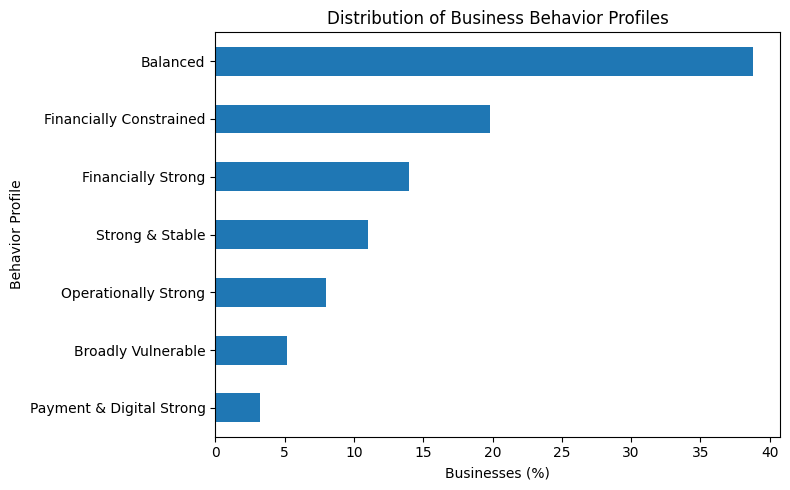

In [16]:
import matplotlib.pyplot as plt

profile_distribution.sort_values("percentage").plot(
    x="behavior_profile",
    y="percentage",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)

plt.xlabel("Businesses (%)")
plt.ylabel("Behavior Profile")
plt.title("Distribution of Business Behavior Profiles")
plt.tight_layout()
plt.show()

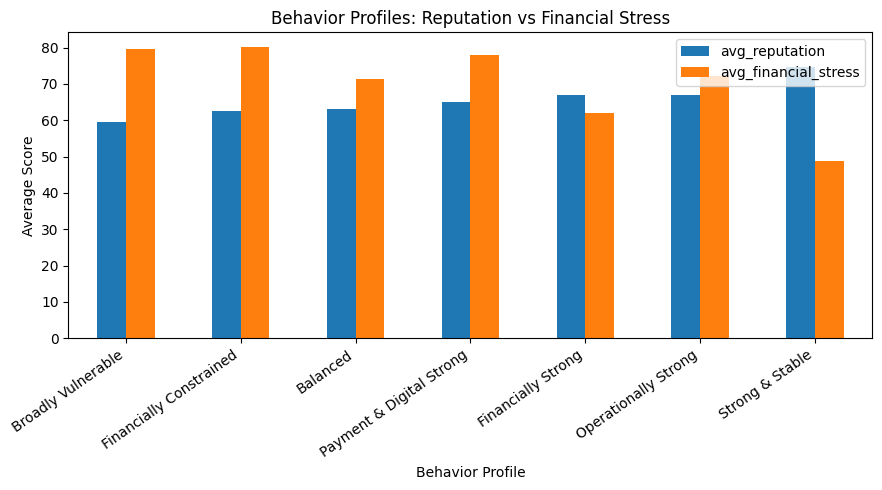

In [17]:
profile_summary.sort_values("avg_reputation")[
    ["avg_reputation", "avg_financial_stress"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Behavior Profile")
plt.ylabel("Average Score")
plt.title("Behavior Profiles: Reputation vs Financial Stress")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Key Findings — Economic Behavior Analysis

- **Balanced businesses form the largest segment**, representing 38.8% of the business population.
- **19.8% of businesses are Financially Constrained**, showing lower financial health and elevated financial stress.
- **Strong & Stable businesses have the strongest economic profile**, with the highest average reputation (74.80) and strong financial, payment, and operational behavior.
- **Broadly Vulnerable businesses have the lowest average reputation (59.59)** and weaker payment and operational behavior.
- **Operationally Strong businesses demonstrate strong operational behavior (82.88)** despite comparatively lower financial health.
- Behavioral segmentation shows that **economic reputation is closely associated with financial health, payment behavior, and operational strength**, supporting the use of multiple behavioral dimensions in the TrustMesh reputation framework.